# Reproducing ResNet on CIFAR-10: Plain-20 vs ResNet-20

This project reproduces the core ideas presented in the ResNet paper, *Deep Residual Learning for Image Recognition* (He et al., 2015).

The objective is to investigate how residual (skip) connections affect the optimization and performance of deep convolutional neural networks. To study this, two architectures were implemented and compared on the CIFAR-10 dataset:

- Plain-20: A 20-layer convolutional neural network without residual connections.
- ResNet-20: A 20-layer residual network containing shortcut connections between layers.

The experiments were conducted using TensorFlow/Keras on the CIFAR-10 image classification dataset. Performance was evaluated in terms of training loss, training accuracy, test loss, and test accuracy.

The implementation process also involved debugging optimization issues in deep plain networks, introducing Batch Normalization for stable training, and analyzing the effect of residual learning on network performance.

## Objectives

- Implement a Plain-20 convolutional neural network.
- Implement a ResNet-20 architecture using residual blocks.
- Compare optimization behavior between plain and residual networks.
- Evaluate the impact of residual connections on classification performance.
- Reproduce the key qualitative findings of the original ResNet paper.

## Importing Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import ReLU
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Add
from tensorflow.keras.models import Model

## Loading the CIFAR-10 Dataset
The CIFAR-10 dataset contains 60,000 RGB images of size 32×32 belonging to 10 classes. The dataset is divided into 50,000 training images and 10,000 test images.
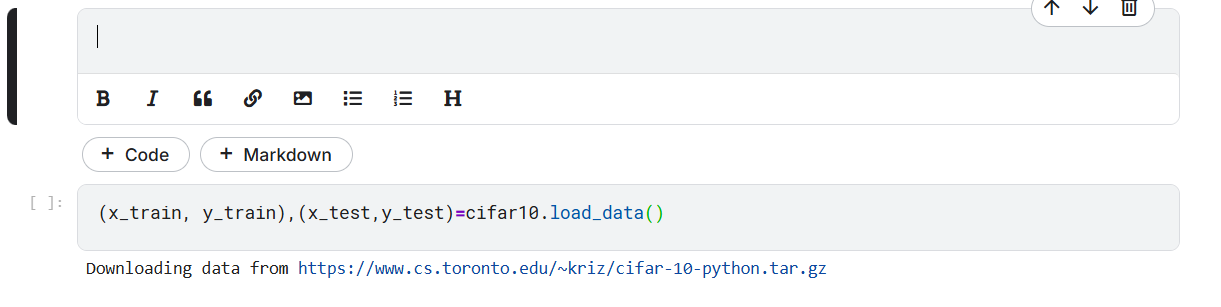

In [5]:
(x_train, y_train),(x_test,y_test)=cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


## Dataset Information
Before preprocessing, pixel values lie in the range [0,255].

In [6]:
print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Test Images Shape:", x_test.shape)
print("Test Labels Shape:", y_test.shape)

print("\nPixel Value Range:")
print("Minimum Pixel Value:", np.min(x_train))
print("Maximum Pixel Value:", np.max(x_train))

Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Test Images Shape: (10000, 32, 32, 3)
Test Labels Shape: (10000, 1)

Pixel Value Range:
Minimum Pixel Value: 0
Maximum Pixel Value: 255


## Data Preprocessing
Pixel values are normalized from the range [0,255] to [0,1] to improve optimization stability and training convergence.

In [7]:
x_train=np.divide(x_train, 255)
x_test=np.divide(x_test, 255)

## Building the Plain-20 Architecture
The Plain-20 network consists of an initial convolutional layer followed by three stages of convolutional blocks. Each block contains two convolutional layers with Batch Normalization and ReLU activation. Unlike ResNet, no shortcut connections are used.

### Helper Function: add_stage()

To reduce code duplication, a helper function is created to construct a stage of the Plain-20 network. Each stage consists of multiple convolutional blocks, where every block contains:

- Convolution (3×3)
- Batch Normalization
- ReLU Activation
- Convolution (3×3)
- Batch Normalization
- ReLU Activation

The first block of a stage can optionally perform downsampling using a stride of 2.

In [9]:
def add_stage(model, filters, num_block, downsampling=False):

    for block in range(num_block):
        stride=1
        if(downsampling and block==0):
            stride=2

        model.add(
            Conv2D(
                filters=filters,
                kernel_size=(3,3),
                use_bias=False,
                strides=stride,
                padding='same',
            )
        )
        model.add(BatchNormalization())
        model.add(ReLU())

        model.add(
            Conv2D(
                filters=filters,
                kernel_size=(3,3),
                use_bias=False,
                padding='same'
            )        
        )
        model.add(BatchNormalization())
        model.add(ReLU())



## Constructing the Plain-20 Network
The Plain-20 architecture consists of an initial convolutional layer followed by three stages with feature dimensions 16, 32, and 64 respectively. Global Average Pooling is applied before the final softmax classifier.

### Architecture Configuration

The Plain-20 network follows the design proposed in the ResNet paper for CIFAR-10. It consists of:

- An initial 3×3 convolution layer with 16 filters.
- Stage 1: Three residual-style blocks operating at 32×32 resolution with 16 filters.
- Stage 2: Three blocks operating at 16×16 resolution with 32 filters.
- Stage 3: Three blocks operating at 8×8 resolution with 64 filters.
- Global Average Pooling.
- A 10-class softmax classifier.

In [10]:
model_1=Sequential()

model_1.add(
    Conv2D(
        filters=16,
        kernel_size=(3,3),
        padding='same',
        use_bias=False,
        input_shape=(32,32,3)
    )
)
model_1.add(BatchNormalization())
model_1.add(ReLU())

#stage 1
add_stage(model_1, 16, 3, False)

#stage2
add_stage(model_1,32,3,True)

#stage3
add_stage(model_1,64,3,True)

model_1.add(GlobalAveragePooling2D())
model_1.add(
    Dense(units=10, activation='softmax')
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-15 17:47:27.148407: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Plain-20 Model Summary

In [11]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 16)     │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 16)     │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 16)     │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 16)     │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 271,098 (1.03 MB)

 Trainable params: 269,722 (1.03 MB)

 Non-trainable params: 1,376 (5.38 KB)

## Model Compilation
The Plain-20 network is trained using the Adam optimizer with a learning rate of 0.001. Sparse Categorical Crossentropy is used as the loss function since CIFAR-10 labels are represented as integer class indices.

In [12]:
model_1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
             loss=SparseCategoricalCrossentropy(),
               metrics=['accuracy'])

## Training the Plain-20 Network
The model is trained for 10 epochs on the CIFAR-10 training set. Training accuracy and loss are monitored throughout the optimization process.

In [13]:
history_plain20 = model_1.fit(
    x_train,
    y_train,
    epochs=10
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 283s 174ms/step - accuracy: 0.3978 - loss: 1.6101
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 271s 174ms/step - accuracy: 0.5907 - loss: 1.1372
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 272s 174ms/step - accuracy: 0.6792 - loss: 0.9159
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 275s 176ms/step - accuracy: 0.7253 - loss: 0.7853
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 275s 176ms/step - accuracy: 0.7575 - loss: 0.6974
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 272s 174ms/step - accuracy: 0.7830 - loss: 0.6274
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 273s 175ms/step - accuracy: 0.8038 - loss: 0.5703
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 272s 174ms/step - accuracy: 0.8198 - loss: 0.5197
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 271s 173ms/step - accuracy: 0.8359 - loss: 0.4769
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 272s 174ms/step - accuracy: 0.8440 - loss: 0.4483


## Evaluating the Plain-20 Network
The trained Plain-20 network is evaluated on both the training and test datasets to measure optimization performance and generalization capability.

In [16]:
model_1.evaluate(x_train,y_train)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.7937 - loss: 0.5934


[0.5934152603149414, 0.7936800122261047]

In [17]:
model_1.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.7379 - loss: 0.8264


[0.8263996243476868, 0.7379000186920166]

## Plain-20 Results

| Metric | Value |
|----------|----------|
| Training Loss | 0.5934 |
| Training Accuracy | 79.37% |
| Test Loss | 0.8264 |
| Test Accuracy | 73.79% |

### Observations

The Plain-20 network successfully converged after the introduction of Batch Normalization. Training accuracy reached approximately 79.37%, while test accuracy reached 73.79%.

Although the network learned meaningful image representations, a noticeable gap between training and test performance indicates some degree of overfitting. These results serve as a baseline for comparison with the ResNet-20 architecture.

# ResNet-20 Architecture

In this section, the ResNet-20 architecture is implemented using TensorFlow/Keras Functional API. Unlike the Plain-20 network, ResNet introduces shortcut (residual) connections that allow gradients to flow directly through the network, making deeper models easier to optimize.

The architecture follows the design proposed in the original ResNet paper for CIFAR-10 and consists of three stages with feature dimensions 16, 32, and 64.

## Building Residual Blocks

A residual block contains two convolutional layers along with a shortcut connection. The output of the convolutional path is added to the shortcut path before applying the final activation function.

In [19]:
def residual_block(x,filters,downsample=False):
    shortcut=x
    if(downsample):
        stride=2

    else:
        stride=1
    x=Conv2D(
        filters=filters,
        kernel_size=(3,3),
        padding='same',
        use_bias=False,
        strides=stride
    )(x)
    x=BatchNormalization()(x)
    x=ReLU()(x)
    x=Conv2D(
        filters=filters,
        kernel_size=(3,3),
        strides=1,
        padding='same',
        use_bias=False,
    )(x)
    x=BatchNormalization()(x)
    if downsample:
        shortcut = Conv2D(
            filters=filters,
            kernel_size=(1,1),
            strides=2,
            padding='same',
            use_bias=False
        )(shortcut)

        shortcut = BatchNormalization()(shortcut)
    x=Add()([x,shortcut])
    ReLU()(x)
    
    return x

## Constructing the ResNet-20 Architecture

### Architecture Configuration

The ResNet-20 model begins with an initial 3×3 convolution layer followed by three stages of residual blocks.

- Stage 1: Three residual blocks with 16 filters.
- Stage 2: Three residual blocks with 32 filters (first block performs downsampling).
- Stage 3: Three residual blocks with 64 filters (first block performs downsampling).
- Global Average Pooling.
- Fully connected softmax classifier for 10 CIFAR-10 classes.

The architecture contains 20 weighted layers and follows the configuration proposed in the original ResNet paper for CIFAR-10.

In [20]:
inputs=Input(shape=(32,32,3))

In [21]:
x=Conv2D(
    filters=16,
    kernel_size=(3,3),
    padding='same',
    use_bias=False,
)(inputs)

x=BatchNormalization()(x)
x=ReLU()(x)



In [22]:
#stage 1
x=residual_block(x,16)
x=residual_block(x,16)
x=residual_block(x,16)

#stage 2
x=residual_block(x,32,downsample=True)
x=residual_block(x,32)
x=residual_block(x,32)

#stage 3
x=residual_block(x,64,downsample=True)
x=residual_block(x,64)
x=residual_block(x,64)

In [23]:
x=GlobalAveragePooling2D()(x)
x=Dense(
    units=10, 
    activation='softmax'
)(x)

In [24]:
model_2=Model(
    inputs=inputs,
    outputs=x
)

## ResNet-20 Model Summary

In [25]:
model_2.summary()

Model: "functional_59"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │        432 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │      2,304 │ re_lu_19[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │      2,304 │ re_lu_20[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │ re_lu_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │      2,304 │ add[0][0]         │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_22 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │      2,304 │ re_lu_22[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │      2,304 │ add_1[0][0]     

 Total params: 274,042 (1.05 MB)

 Trainable params: 272,474 (1.04 MB)

 Non-trainable params: 1,568 (6.12 KB)

## Model Compilation
The network is trained using the Adam optimizer with a learning rate of 0.001 and Sparse Categorical Crossentropy loss.

In [26]:
model_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
             loss=SparseCategoricalCrossentropy(),
               metrics=['accuracy'])

## Training the ResNet-20 Network

In [27]:
history_resnet20 = model_2.fit(
    x_train,
    y_train,
    epochs=10
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 291s 178ms/step - accuracy: 0.5277 - loss: 1.3099
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 282s 181ms/step - accuracy: 0.6781 - loss: 0.9107
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 282s 180ms/step - accuracy: 0.7343 - loss: 0.7565
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 281s 180ms/step - accuracy: 0.7684 - loss: 0.6623
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 280s 179ms/step - accuracy: 0.7960 - loss: 0.5900
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 280s 179ms/step - accuracy: 0.8149 - loss: 0.5325
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 280s 179ms/step - accuracy: 0.8317 - loss: 0.4812
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 280s 179ms/step - accuracy: 0.8478 - loss: 0.4388
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 278s 178ms/step - accuracy: 0.8611 - loss: 0.3930
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 278s 178ms/step - accuracy: 0.8727 - loss: 0.3581


## Evaluating the ResNet-20 Network

In [28]:
model_2.evaluate(x_train,y_train)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.8784 - loss: 0.3530


[0.3529669940471649, 0.8783800005912781]

In [29]:
model_2.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.7964 - loss: 0.6349


[0.6349453926086426, 0.7964000105857849]

## ResNet-20 Results

| Metric | Value |
|----------|----------|
| Training Loss | 0.3530 |
| Training Accuracy | 87.84% |
| Test Loss | 0.6349 |
| Test Accuracy | 79.64% |

### Observations

The ResNet-20 model converged successfully and achieved higher training and test accuracy than the Plain-20 network. The residual shortcut connections improved optimization and enabled more effective learning in a deep architecture.

# Plain-20 vs ResNet-20 Comparison

| Model | Train Accuracy | Test Accuracy |
|----------|----------:|----------:|
| Plain-20 | 79.37% | 73.79% |
| ResNet-20 | 87.84% | 79.64% |

### Analysis

Both architectures contain approximately the same depth and were trained under identical conditions on the CIFAR-10 dataset.

The ResNet-20 model achieved higher training and test accuracy than the Plain-20 network. This improvement can be attributed to residual shortcut connections, which facilitate gradient flow and make optimization easier in deeper networks.

The results support the central claim of the original ResNet paper: residual learning enables deeper neural networks to train more effectively than equivalent plain architectures.

## Training Curves

The following plots compare the training behavior of Plain-20 and ResNet-20. Training accuracy and loss are tracked across epochs to analyze optimization performance.

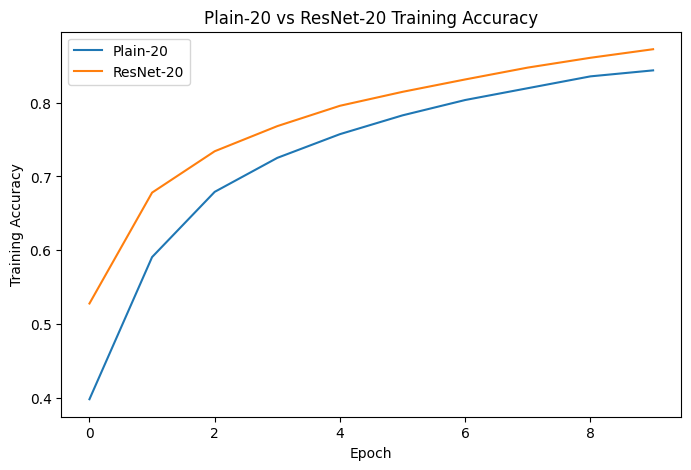

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history_plain20.history['accuracy'], label='Plain-20')
plt.plot(history_resnet20.history['accuracy'], label='ResNet-20')

plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Plain-20 vs ResNet-20 Training Accuracy')
plt.legend()

plt.show()

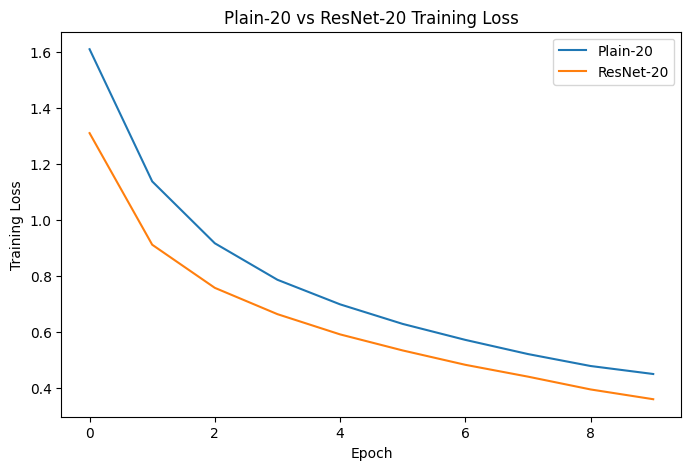

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history_plain20.history['loss'], label='Plain-20')
plt.plot(history_resnet20.history['loss'], label='ResNet-20')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Plain-20 vs ResNet-20 Training Loss')
plt.legend()

plt.show()

# Conclusion

In this notebook, the Plain-20 and ResNet-20 architectures from the ResNet paper were implemented and evaluated on the CIFAR-10 dataset.

The Plain-20 model achieved a test accuracy of 73.79%, while ResNet-20 achieved 79.64%. Although the improvement is modest at this depth and training duration, the residual network consistently outperformed the plain architecture.

This experiment demonstrates the practical benefits of residual learning and provides a foundation for further experiments with deeper networks such as Plain-32 and ResNet-32.